In [1]:
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: []


In [4]:
tf.random.set_seed(42)
np.random.seed(42)

In [5]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth configured successfully!")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    print("No GPU detected. Training will use CPU (slower).")

No GPU detected. Training will use CPU (slower).


In [6]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))
print("CUDA available:", tf.test.is_built_with_cuda())

TensorFlow version: 2.20.0
GPU devices: []
CUDA available: False


In [7]:
import tensorflow as tf

# Use all available CPU cores
tf.config.threading.set_intra_op_parallelism_threads(0)  # 0 = use all cores
tf.config.threading.set_inter_op_parallelism_threads(0)

In [8]:
BASE_PATH = os.path.join(os.path.expanduser('~'), 'Desktop', 'BrainTumorProject', 'archive')
TRAIN_DIR = os.path.join(BASE_PATH, 'Training')
TEST_DIR = os.path.join(BASE_PATH, 'Testing')

print(f"Base path: {BASE_PATH}")
print(f"Training data: {TRAIN_DIR}")
print(f"Testing data: {TEST_DIR}")

# Verify paths exist
print(f"Training folder exists: {os.path.exists(TRAIN_DIR)}")
print(f"Testing folder exists: {os.path.exists(TEST_DIR)}")

Base path: C:\Users\Akash\Desktop\BrainTumorProject\archive
Training data: C:\Users\Akash\Desktop\BrainTumorProject\archive\Training
Testing data: C:\Users\Akash\Desktop\BrainTumorProject\archive\Testing
Training folder exists: True
Testing folder exists: True


In [9]:
if os.path.exists(TRAIN_DIR):
    classes = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
    classes.sort()  # Sort for consistency
    print(f"Detected classes: {classes}")
    print(f"Number of classes: {len(classes)}")
    
    print("\n--- Training Data Distribution ---")
    for class_name in classes:
        class_path = os.path.join(TRAIN_DIR, class_name)
        img_count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"{class_name}: {img_count} images")
    
    print("\n--- Testing Data Distribution ---")
    for class_name in classes:
        class_path = os.path.join(TEST_DIR, class_name)
        if os.path.exists(class_path):
            img_count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            print(f"{class_name}: {img_count} images")
else:
    print("Training directory not found! Please check your folder structure.")

Detected classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4

--- Training Data Distribution ---
glioma: 1321 images
meningioma: 1339 images
notumor: 1595 images
pituitary: 1457 images

--- Testing Data Distribution ---
glioma: 300 images
meningioma: 306 images
notumor: 405 images
pituitary: 300 images


In [10]:
IMG_SIZE = (224, 224)  
NUM_CLASSES = len(classes)
BATCH_SIZE = 16        
EPOCHS = 30          
LEARNING_RATE = 0.0001 

print("=== Training Configuration ===")
print(f"Image size: {IMG_SIZE}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")

=== Training Configuration ===
Image size: (224, 224)
Number of classes: 4
Batch size: 16
Epochs: 30
Learning rate: 0.0001


In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,           
    rotation_range=15,        
    width_shift_range=0.1,    
    height_shift_range=0.1, 
    shear_range=0.1,         
    zoom_range=0.1,         
    horizontal_flip=True,     
    fill_mode='nearest'      
)


val_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # One-hot encoded labels
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,  
    
    seed=42
)

print("Data generators created successfully!")
print(f"Training batches per epoch: {train_generator.samples // BATCH_SIZE}")
print(f"Validation batches: {val_generator.samples // BATCH_SIZE}")
print(f"Class indices: {train_generator.class_indices}")

Found 5712 images belonging to 4 classes.
Found 1312 images belonging to 4 classes.
Data generators created successfully!
Training batches per epoch: 357
Validation batches: 82
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


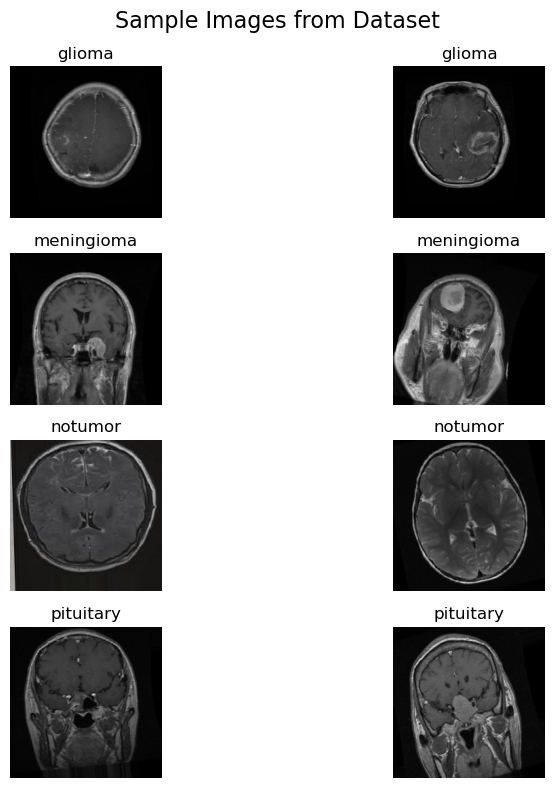

Found 5712 images belonging to 4 classes.


In [12]:
def plot_sample_images(generator, class_names, num_samples=2):
    """Display sample images from each class"""
    fig, axes = plt.subplots(len(class_names), num_samples, figsize=(10, 8))
    fig.suptitle('Sample Images from Dataset', fontsize=16)
    
    # Get a batch of images and labels
    images, labels = next(generator)
    
    # Convert one-hot labels back to class indices
    label_indices = np.argmax(labels, axis=1)
    
    samples_per_class = {i: 0 for i in range(len(class_names))}
    
    for i, (image, label_idx) in enumerate(zip(images, label_indices)):
        if samples_per_class[label_idx] < num_samples:
            row = label_idx
            col = samples_per_class[label_idx]
            
            axes[row, col].imshow(image)
            axes[row, col].set_title(f'{class_names[label_idx]}')
            axes[row, col].axis('off')
            
            samples_per_class[label_idx] += 1
        
        # Stop if we have enough samples for all classes
        if all(count >= num_samples for count in samples_per_class.values()):
            break
    
    plt.tight_layout()
    plt.show()

# Get class names in correct order
class_names = list(train_generator.class_indices.keys())
class_names = [class_names[i] for i in range(len(class_names))]

print("Class names:", class_names)
plot_sample_images(train_generator, class_names)

# Reset generator after visualization
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42
)

In [13]:
def build_vgg19_model(img_size, num_classes, freeze_base=True):
    """
    Build VGG19 model for brain tumor classification
    
    Args:
        img_size: Input image dimensions
        num_classes: Number of tumor classes
        freeze_base: Whether to freeze VGG19 base layers
    
    Returns:
        Compiled Keras model
    """
    
    # Load pre-trained VGG19 without top classification layers
    base_model = VGG19(
        weights='imagenet',      # Use ImageNet pre-trained weights
        include_top=False,       # Exclude final classification layer
        input_shape=(*img_size, 3)  # Input shape: height, width, channels
    )
    
    # Freeze or unfreeze base model layers
    base_model.trainable = not freeze_base
    
    # Add custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)  # Reduce spatial dimensions
    x = Dense(512, activation='relu', name='fc1')(x)       # First dense layer
    x = Dropout(0.5, name='dropout1')(x)                   # Dropout for regularization
    x = Dense(256, activation='relu', name='fc2')(x)       # Second dense layer
    x = Dropout(0.3, name='dropout2')(x)                   # Second dropout
    predictions = Dense(num_classes, activation='softmax', name='predictions')(x)  # Output layer
    
    # Create the complete model
    model = Model(inputs=base_model.input, outputs=predictions, name='VGG19_BrainTumor')
    
    return model

# Build the model
print("Building VGG19 model...")
model = build_vgg19_model(IMG_SIZE, NUM_CLASSES, freeze_base=True)

# Display model summary
print("\n=== MODEL ARCHITECTURE ===")
model.summary()

print(f"\nTotal parameters: {model.count_params():,}")
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {model.count_params() - trainable_params:,}")

Building VGG19 model...

=== MODEL ARCHITECTURE ===


Model: "VGG19_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 20,419,396 (77.89 MB)

 Trainable params: 395,012 (1.51 MB)

 Non-trainable params: 20,024,384 (76.39 MB)


Total parameters: 20,419,396
Trainable parameters: 395,012
Non-trainable parameters: 20,024,384


In [14]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),  # Adam optimizer with specified learning rate
    loss='categorical_crossentropy',              # Loss function for multi-class classification
    metrics=['accuracy', 'precision', 'recall']   # Metrics to monitor during training
)

print("Model compiled successfully!")
print("\nCompilation details:")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Loss function: categorical_crossentropy")
print(f"Metrics: accuracy, precision, recall")

Model compiled successfully!

Compilation details:
Optimizer: Adam (lr=0.0001)
Loss function: categorical_crossentropy
Metrics: accuracy, precision, recall


In [15]:
os.makedirs('models', exist_ok=True)

# Define callbacks
callbacks = [
    # Save the best model based on validation accuracy
    ModelCheckpoint(
        'models/best_vgg19_brain_tumor.keras',
        monitor='val_accuracy',     # Monitor validation accuracy
        save_best_only=True,        # Only save if current model is better
        save_weights_only=False,    # Save entire model, not just weights
        mode='max',                 # Save when val_accuracy is maximum
        verbose=1                   # Print when saving
    ),
    
    # Stop training early if model stops improving
    EarlyStopping(
        monitor='val_loss',         # Monitor validation loss
        patience=8,                 # Wait 8 epochs before stopping
        restore_best_weights=True,  # Restore best weights when stopping
        verbose=1
    ),
    
    # Reduce learning rate when model plateaus
    ReduceLROnPlateau(
        monitor='val_loss',         # Monitor validation loss
        factor=0.5,                 # Reduce LR by half
        patience=4,                 # Wait 4 epochs before reducing
        min_lr=1e-7,               # Minimum learning rate
        verbose=1
    )
]

print("Callbacks configured:")
print("ModelCheckpoint: Saves best model")
print("EarlyStopping: Prevents overfitting")
print("ReduceLROnPlateau: Adjusts learning rate")

Callbacks configured:
ModelCheckpoint: Saves best model
EarlyStopping: Prevents overfitting
ReduceLROnPlateau: Adjusts learning rate


In [16]:
print("Starting VGG19 training for brain tumor classification...")
print(f"Training on {train_generator.samples} images")
print(f"Validating on {val_generator.samples} images")
print("-" * 50)

# Calculate steps per epoch
steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = val_generator.samples // BATCH_SIZE

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1  # Show progress bar
)

print("\n" + "="*50)
print("TRAINING COMPLETED!")
print("="*50)


Starting VGG19 training for brain tumor classification...
Training on 5712 images
Validating on 1312 images
--------------------------------------------------
Steps per epoch: 357
Validation steps: 82


C:\Users\Akash\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3425 - loss: 1.3740 - precision: 0.4677 - recall: 0.0527  
Epoch 1: val_accuracy improved from None to 0.62119, saving model to models/best_vgg19_brain_tumor.keras
357/357 ━━━━━━━━━━━━━━━━━━━━ 637s 2s/step - accuracy: 0.4116 - loss: 1.2783 - precision: 0.6499 - recall: 0.0884 - val_accuracy: 0.6212 - val_loss: 0.9971 - val_precision: 0.8837 - val_recall: 0.2607 - learning_rate: 1.0000e-04
Epoch 2/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5966 - loss: 0.9749 - precision: 0.7757 - recall: 0.3092  
Epoch 2: val_accuracy improved from 0.62119 to 0.66311, saving model to models/best_vgg19_brain_tumor.keras
357/357 ━━━━━━━━━━━━━━━━━━━━ 655s 2s/step - accuracy: 0.6166 - loss: 0.9161 - precision: 0.7768 - recall: 0.3606 - val_accuracy: 0.6631 - val_loss: 0.8326 - val_precision: 0.7855 - val_recall: 0.4634 - learning_rate: 1.0000e-04
Epoch 3/30
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6769 - loss: 0.780

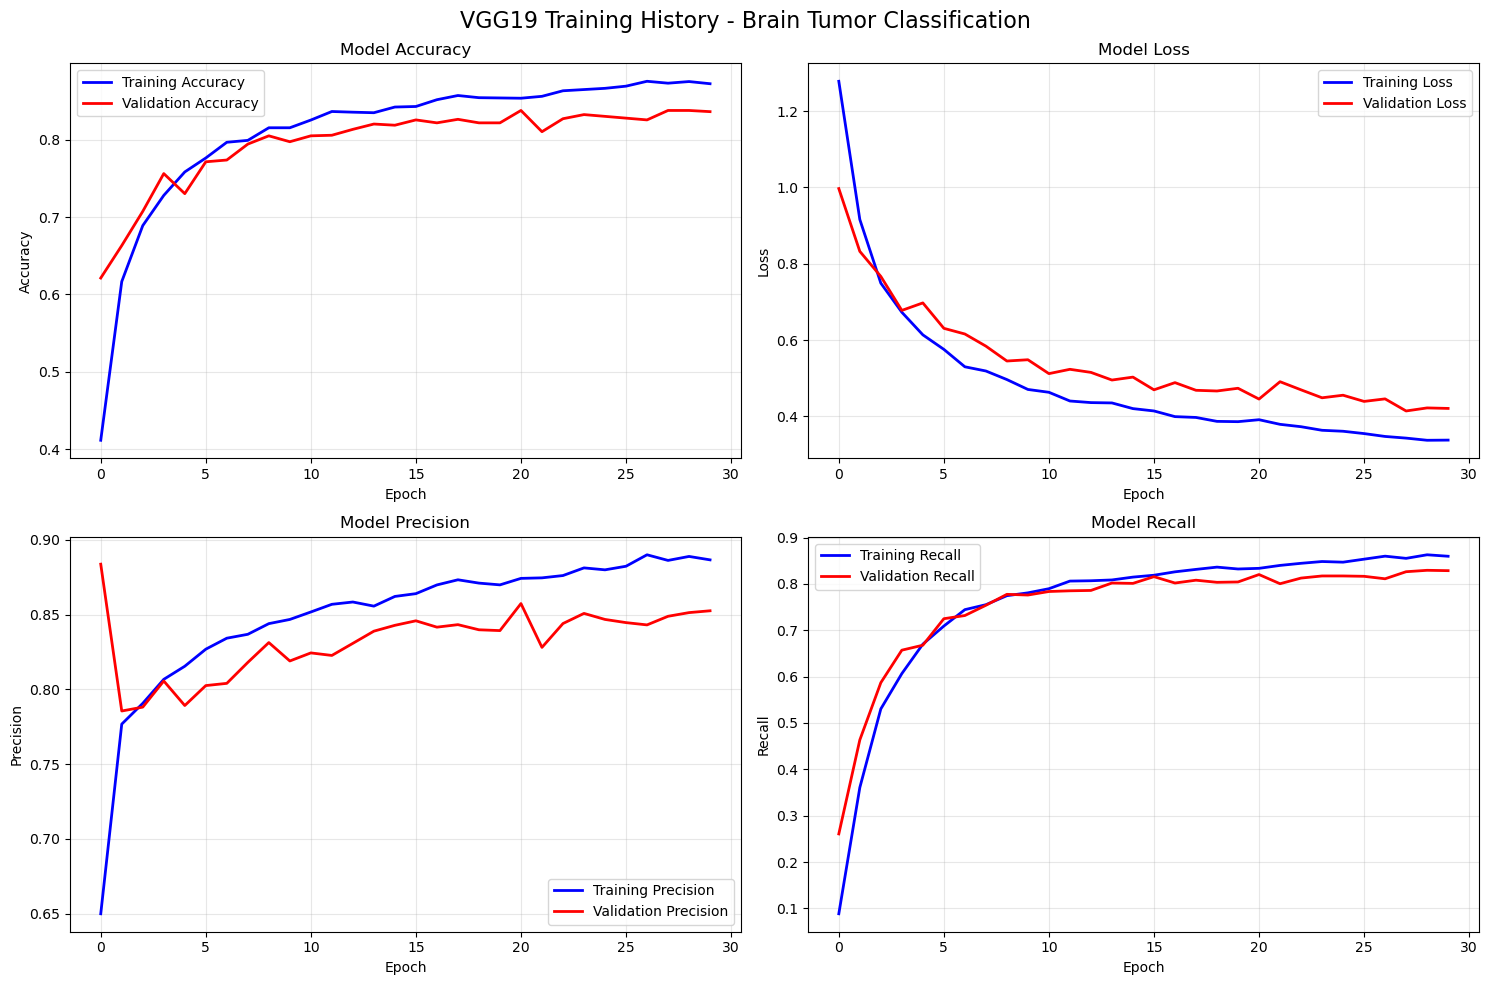


=== FINAL TRAINING RESULTS ===
Final Training Accuracy: 0.8722
Final Validation Accuracy: 0.8361
Final Training Loss: 0.3381
Final Validation Loss: 0.4211


In [17]:
def plot_training_history(history):
    """
    Plot training and validation metrics over epochs
    """
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('VGG19 Training History - Brain Tumor Classification', fontsize=16)
    
    # Plot accuracy
    axes[0, 0].plot(history.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot loss
    axes[0, 1].plot(history.history['loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot precision
    axes[1, 0].plot(history.history['precision'], 'b-', label='Training Precision', linewidth=2)
    axes[1, 0].plot(history.history['val_precision'], 'r-', label='Validation Precision', linewidth=2)
    axes[1, 0].set_title('Model Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot recall
    axes[1, 1].plot(history.history['recall'], 'b-', label='Training Recall', linewidth=2)
    axes[1, 1].plot(history.history['val_recall'], 'r-', label='Validation Recall', linewidth=2)
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('models/training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot the training history
plot_training_history(history)

# Print final training results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"\n=== FINAL TRAINING RESULTS ===")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

In [18]:
best_model = tf.keras.models.load_model('models/best_vgg19_brain_tumor.keras')
print("Best model loaded successfully!")

# Make predictions on validation set
print("Making predictions on test set...")
val_generator.reset()  # Reset generator to start from beginning
predictions = best_model.predict(val_generator, steps=validation_steps, verbose=1)

# Get true labels
true_labels = val_generator.classes[:len(predictions)]
predicted_labels = np.argmax(predictions, axis=1)

# Calculate accuracy
test_accuracy = np.mean(predicted_labels == true_labels)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Create classification report
class_names_ordered = [list(val_generator.class_indices.keys())[i] for i in range(NUM_CLASSES)]
report = classification_report(true_labels, predicted_labels, 
                             target_names=class_names_ordered, 
                             output_dict=True)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predicted_labels, target_names=class_names_ordered))

Best model loaded successfully!
Making predictions on test set...
82/82 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step

Test Accuracy: 0.8377

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      glioma       0.87      0.72      0.79       301
  meningioma       0.73      0.68      0.70       306
     notumor       0.90      0.95      0.92       405
   pituitary       0.83      0.97      0.89       300

    accuracy                           0.84      1312
   macro avg       0.83      0.83      0.83      1312
weighted avg       0.84      0.84      0.83      1312



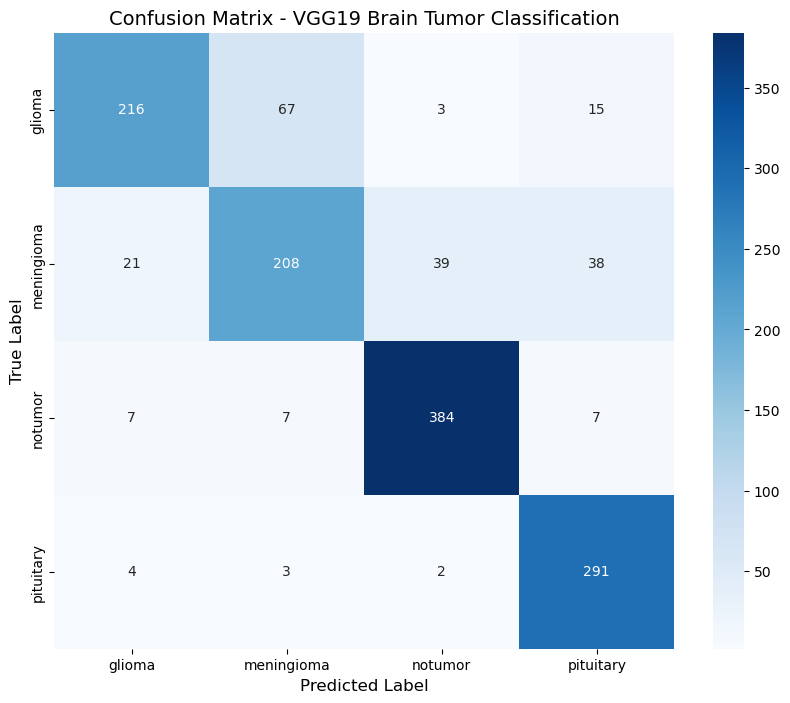


=== PER-CLASS PERFORMANCE ===
glioma:
  Accuracy: 0.718
  Precision: 0.871
  Recall: 0.718
  F1-Score: 0.787

meningioma:
  Accuracy: 0.680
  Precision: 0.730
  Recall: 0.680
  F1-Score: 0.704

notumor:
  Accuracy: 0.948
  Precision: 0.897
  Recall: 0.948
  F1-Score: 0.922

pituitary:
  Accuracy: 0.970
  Precision: 0.829
  Recall: 0.970
  F1-Score: 0.894



In [19]:
cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_ordered, 
            yticklabels=class_names_ordered)
plt.title('Confusion Matrix - VGG19 Brain Tumor Classification', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.savefig('models/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate per-class accuracy
print("\n=== PER-CLASS PERFORMANCE ===")
for i, class_name in enumerate(class_names_ordered):
    class_accuracy = cm[i, i] / cm[i].sum()
    precision = report[class_name]['precision']
    recall = report[class_name]['recall']
    f1_score = report[class_name]['f1-score']
    
    print(f"{class_name}:")
    print(f"  Accuracy: {class_accuracy:.3f}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print(f"  F1-Score: {f1_score:.3f}")
    print()


In [20]:
summary = {
    'model': 'VGG19',
    'dataset_size': {
        'training': train_generator.samples,
        'validation': val_generator.samples,
        'total': train_generator.samples + val_generator.samples
    },
    'classes': class_names_ordered,
    'training_config': {
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'image_size': IMG_SIZE
    },
    'final_results': {
        'training_accuracy': final_train_acc,
        'validation_accuracy': final_val_acc,
        'test_accuracy': test_accuracy,
        'training_loss': final_train_loss,
        'validation_loss': final_val_loss
    }
}

# Save summary to file
import json
with open('models/training_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print("=== TRAINING SUMMARY ===")
print(f"Model: VGG19")
print(f"Total training images: {summary['dataset_size']['training']}")
print(f"Total validation images: {summary['dataset_size']['validation']}")
print(f"Classes: {', '.join(summary['classes'])}")
print(f"Training epochs: {EPOCHS}")
print(f"Final test accuracy: {test_accuracy:.4f}")
print(f"\nAll results saved to 'models/' directory")
print("✓ Best model: best_vgg19_brain_tumor.keras")
print("✓ Training plots: training_history.png")
print("✓ Confusion matrix: confusion_matrix.png")
print("✓ Training summary: training_summary.json")

print("\n🎉 VGG19 training completed successfully!")
print("Next steps: Implement GradCAM for tumor localization")

=== TRAINING SUMMARY ===
Model: VGG19
Total training images: 5712
Total validation images: 1312
Classes: glioma, meningioma, notumor, pituitary
Training epochs: 30
Final test accuracy: 0.8377

All results saved to 'models/' directory
✓ Best model: best_vgg19_brain_tumor.keras
✓ Training plots: training_history.png
✓ Confusion matrix: confusion_matrix.png
✓ Training summary: training_summary.json

🎉 VGG19 training completed successfully!
Next steps: Implement GradCAM for tumor localization


In [14]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
import os

print("Loading best VGG19 model...")
model = load_model('models/best_vgg19_brain_tumor.h5')

print("Model loaded successfully!")
print(f"Current test accuracy: 83.77%")
print("\nPreparing for fine-tuning to improve accuracy...")

Loading best VGG19 model...


Model loaded successfully!
Current test accuracy: 83.77%

Preparing for fine-tuning to improve accuracy...


In [15]:
print("Model structure:")
for i, layer in enumerate(model.layers):
    print(f"Layer {i}: {layer.name} - {type(layer).__name__}")

print("\n" + "="*60)

if hasattr(model.layers[0], 'layers'):
    base_model = model.layers[0]
    print("VGG19 base found as first layer")
else:
    base_model = model
    print("Using entire model")

print(f"Total layers in base model: {len(base_model.layers)}")

for layer in base_model.layers:
    layer.trainable = True

total_layers = len(base_model.layers)
freeze_until = total_layers - 8

print(f"\nFreezing first {freeze_until} layers")
print(f"Training last {total_layers - freeze_until} layers")

for i, layer in enumerate(base_model.layers):
    if i < freeze_until:
        layer.trainable = False
    else:
        layer.trainable = True
        print(f"  Trainable: {layer.name}")

trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
total_params = model.count_params()

print(f"\n{'='*60}")
print("FINE-TUNING CONFIGURATION")
print(f"{'='*60}")
print(f"Total layers: {total_layers}")
print(f"Frozen layers: {freeze_until}")
print(f"Trainable layers: {total_layers - freeze_until}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")
print(f"Percentage trainable: {(trainable_params/total_params)*100:.2f}%")

Model structure:
Layer 0: input_layer - InputLayer
Layer 1: block1_conv1 - Conv2D
Layer 2: block1_conv2 - Conv2D
Layer 3: block1_pool - MaxPooling2D
Layer 4: block2_conv1 - Conv2D
Layer 5: block2_conv2 - Conv2D
Layer 6: block2_pool - MaxPooling2D
Layer 7: block3_conv1 - Conv2D
Layer 8: block3_conv2 - Conv2D
Layer 9: block3_conv3 - Conv2D
Layer 10: block3_conv4 - Conv2D
Layer 11: block3_pool - MaxPooling2D
Layer 12: block4_conv1 - Conv2D
Layer 13: block4_conv2 - Conv2D
Layer 14: block4_conv3 - Conv2D
Layer 15: block4_conv4 - Conv2D
Layer 16: block4_pool - MaxPooling2D
Layer 17: block5_conv1 - Conv2D
Layer 18: block5_conv2 - Conv2D
Layer 19: block5_conv3 - Conv2D
Layer 20: block5_conv4 - Conv2D
Layer 21: block5_pool - MaxPooling2D
Layer 22: global_avg_pool - GlobalAveragePooling2D
Layer 23: fc1 - Dense
Layer 24: dropout1 - Dropout
Layer 25: fc2 - Dense
Layer 26: dropout2 - Dropout
Layer 27: predictions - Dense

Using entire model
Total layers in base model: 28

Freezing first 20 layers
T

In [16]:
FINE_TUNE_LR = 0.00001

model.compile(
    optimizer=Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print("Model recompiled for fine-tuning!")
print(f"New learning rate: {FINE_TUNE_LR}")
print("This slower learning rate prevents destroying pre-trained features")

Model recompiled for fine-tuning!
New learning rate: 1e-05
This slower learning rate prevents destroying pre-trained features


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

BASE_PATH = os.path.join(os.path.expanduser('~'), 'Desktop', 'BrainTumorProject', 'archive')
TRAIN_DIR = os.path.join(BASE_PATH, 'Training')
TEST_DIR = os.path.join(BASE_PATH, 'Testing')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print("Data generators recreated!")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Found 5712 images belonging to 4 classes.
Found 1312 images belonging to 4 classes.
Data generators recreated!
Training samples: 5712
Validation samples: 1312


In [18]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

fine_tune_callbacks = [
    ModelCheckpoint(
        'models/fine_tuned_vgg19_brain_tumor.h5',
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,  # More patience for fine-tuning
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-8,
        verbose=1
    )
]

print("Fine-tuning callbacks configured!")
print("Will save best model as: fine_tuned_vgg19_brain_tumor.h5")
print("Early stopping with patience=10")
print("Learning rate reduction enabled")

Fine-tuning callbacks configured!
Will save best model as: fine_tuned_vgg19_brain_tumor.h5
Early stopping with patience=10
Learning rate reduction enabled


In [9]:
FINE_TUNE_EPOCHS = 20

print("="*60)
print("STARTING FINE-TUNING")
print("="*60)
print(f"Previous best accuracy: 83.77%")
print(f"Target accuracy: 90%+")
print(f"Fine-tuning epochs: {FINE_TUNE_EPOCHS}")
print(f"Learning rate: {FINE_TUNE_LR}")
print("-"*60)

steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = val_generator.samples // BATCH_SIZE

fine_tune_history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks,
    verbose=1
)

print("\n" + "="*60)
print("FINE-TUNING COMPLETED!")
print("="*60)

STARTING FINE-TUNING
Previous best accuracy: 83.77%
Target accuracy: 90%+
Fine-tuning epochs: 20
Learning rate: 1e-05
------------------------------------------------------------


C:\Users\Akash\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7751 - loss: 0.5853 - precision: 0.8240 - recall: 0.6828  
Epoch 1: val_accuracy improved from None to 0.79421, saving model to models/fine_tuned_vgg19_brain_tumor.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 650s 2s/step - accuracy: 0.7822 - loss: 0.5685 - precision: 0.8277 - recall: 0.7024 - val_accuracy: 0.7942 - val_loss: 0.5797 - val_precision: 0.8200 - val_recall: 0.7500 - learning_rate: 1.0000e-05
Epoch 2/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8135 - loss: 0.5023 - precision: 0.8490 - recall: 0.7700  
Epoch 2: val_accuracy improved from 0.79421 to 0.80412, saving model to models/fine_tuned_vgg19_brain_tumor.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 648s 2s/step - accuracy: 0.8144 - loss: 0.4905 - precision: 0.8507 - recall: 0.7721 - val_accuracy: 0.8041 - val_loss: 0.5376 - val_precision: 0.8295 - val_recall: 0.7713 - learning_rate: 1.0000e-05
Epoch 3/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8323 - loss: 0.4485 - precision: 0.8580 - recall: 0.7944  
Epoch 3: val_accuracy improved from 0.80412 to 0.82165, saving model to models/fine_tuned_vgg19_brain_tumor.h5


...

357/357 ━━━━━━━━━━━━━━━━━━━━ 687s 2s/step - accuracy: 0.8969 - loss: 0.2896 - precision: 0.9065 - recall: 0.8846 - val_accuracy: 0.8697 - val_loss: 0.3444 - val_precision: 0.8818 - val_recall: 0.8582 - learning_rate: 1.0000e-05
Epoch 14/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8981 - loss: 0.2950 - precision: 0.9071 - recall: 0.8839  
Epoch 14: val_accuracy did not improve from 0.86966
357/357 ━━━━━━━━━━━━━━━━━━━━ 706s 2s/step - accuracy: 0.9025 - loss: 0.2797 - precision: 0.9120 - recall: 0.8895 - val_accuracy: 0.8643 - val_loss: 0.3487 - val_precision: 0.8788 - val_recall: 0.8567 - learning_rate: 1.0000e-05
Epoch 15/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8988 - loss: 0.2819 - precision: 0.9132 - recall: 0.8867  
Epoch 15: val_accuracy improved from 0.86966 to 0.87729, saving model to models/fine_tuned_vgg19_brain_tumor.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 734s 2s/step - accuracy: 0.8974 - loss: 0.2877 - precision: 0.9082 - recall: 0.8852 - val_accuracy: 0.8773 - val_loss: 0.3268 - val_precision: 0.8853 - val_recall: 0.8651 - learning_rate: 1.0000e-05
Epoch 16/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8965 - loss: 0.2937 - precision: 0.9060 - recall: 0.8887  
Epoch 16: val_accuracy did not improve from 0.87729
357/357 ━━━━━━━━━━━━━━━━━━━━ 716s 2s/step - accuracy: 0.9028 - loss: 0.2777 - precision: 0.9124 - recall: 0.8937 - val_accuracy: 0.8704 - val_loss: 0.3483 - val_precision: 0.8809 - val_recall: 0.8567 - learning_rate: 1.0000e-05
Epoch 17/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8991 - loss: 0.2721 - precision: 0.9140 - recall: 0.8904  
Epoch 17: val_accuracy improved from 0.87729 to 0.88186, saving model to models/fine_tuned_vgg19_brain_tumor.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 714s 2s/step - accuracy: 0.9077 - loss: 0.2592 - precision: 0.9192 - recall: 0.8983 - val_accuracy: 0.8819 - val_loss: 0.3198 - val_precision: 0.8929 - val_recall: 0.8704 - learning_rate: 1.0000e-05
Epoch 18/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9110 - loss: 0.2580 - precision: 0.9212 - recall: 0.9023   
Epoch 18: val_accuracy improved from 0.88186 to 0.89024, saving model to models/fine_tuned_vgg19_brain_tumor.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 722s 2s/step - accuracy: 0.9079 - loss: 0.2612 - precision: 0.9183 - recall: 0.8978 - val_accuracy: 0.8902 - val_loss: 0.3048 - val_precision: 0.8967 - val_recall: 0.8803 - learning_rate: 1.0000e-05
Epoch 19/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9128 - loss: 0.2379 - precision: 0.9207 - recall: 0.9064   
Epoch 19: val_accuracy improved from 0.89024 to 0.89710, saving model to models/fine_tuned_vgg19_brain_tumor.h5


357/357 ━━━━━━━━━━━━━━━━━━━━ 717s 2s/step - accuracy: 0.9086 - loss: 0.2545 - precision: 0.9179 - recall: 0.9007 - val_accuracy: 0.8971 - val_loss: 0.2829 - val_precision: 0.9026 - val_recall: 0.8895 - learning_rate: 1.0000e-05
Epoch 20/20
357/357 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9105 - loss: 0.2543 - precision: 0.9193 - recall: 0.8985  
Epoch 20: val_accuracy did not improve from 0.89710
357/357 ━━━━━━━━━━━━━━━━━━━━ 738s 2s/step - accuracy: 0.9133 - loss: 0.2475 - precision: 0.9222 - recall: 0.9030 - val_accuracy: 0.8841 - val_loss: 0.3104 - val_precision: 0.8911 - val_recall: 0.8727 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 19.

FINE-TUNING COMPLETED!


ACCURACY COMPARISON

Before Fine-Tuning:
  Training Accuracy:   0.8722 (87.22%)
  Validation Accuracy: 0.8361 (83.61%)
  Test Accuracy:       0.8377 (83.77%)

After Fine-Tuning:
  Training Accuracy:   0.9133 (91.33%)
  Validation Accuracy: 0.8841 (88.41%)

✨ Improvement: +4.80%


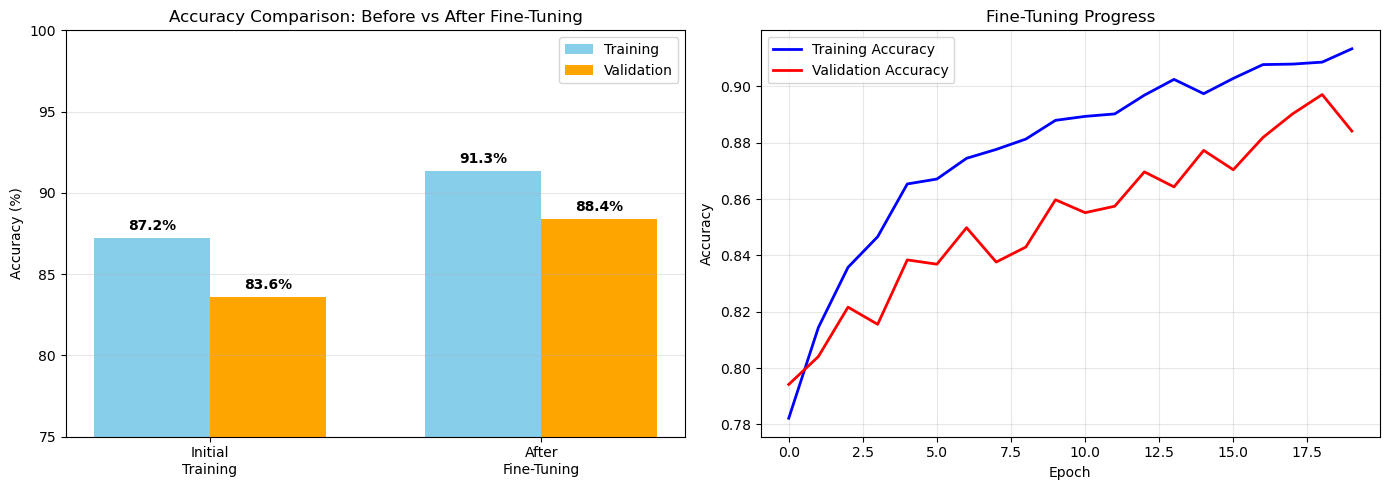

In [10]:
import matplotlib.pyplot as plt
import numpy as np

initial_results = {
    'training_accuracy': 0.8721987979717805,
    'validation_accuracy': 0.8361280560493469,
    'test_accuracy': 0.8376524390243902
}

fine_tune_train_acc = fine_tune_history.history['accuracy'][-1]
fine_tune_val_acc = fine_tune_history.history['val_accuracy'][-1]

print("="*60)
print("ACCURACY COMPARISON")
print("="*60)
print("\nBefore Fine-Tuning:")
print(f"  Training Accuracy:   {initial_results['training_accuracy']:.4f} ({initial_results['training_accuracy']*100:.2f}%)")
print(f"  Validation Accuracy: {initial_results['validation_accuracy']:.4f} ({initial_results['validation_accuracy']*100:.2f}%)")
print(f"  Test Accuracy:       {initial_results['test_accuracy']:.4f} ({initial_results['test_accuracy']*100:.2f}%)")

print("\nAfter Fine-Tuning:")
print(f"  Training Accuracy:   {fine_tune_train_acc:.4f} ({fine_tune_train_acc*100:.2f}%)")
print(f"  Validation Accuracy: {fine_tune_val_acc:.4f} ({fine_tune_val_acc*100:.2f}%)")

val_improvement = (fine_tune_val_acc - initial_results['validation_accuracy']) * 100
print(f"\n✨ Improvement: +{val_improvement:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories = ['Initial\nTraining', 'After\nFine-Tuning']
train_accs = [initial_results['training_accuracy']*100, fine_tune_train_acc*100]
val_accs = [initial_results['validation_accuracy']*100, fine_tune_val_acc*100]

x = np.arange(len(categories))
width = 0.35

axes[0].bar(x - width/2, train_accs, width, label='Training', color='skyblue')
axes[0].bar(x + width/2, val_accs, width, label='Validation', color='orange')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy Comparison: Before vs After Fine-Tuning')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].legend()
axes[0].set_ylim([75, 100])
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(train_accs):
    axes[0].text(i - width/2, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
for i, v in enumerate(val_accs):
    axes[0].text(i + width/2, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].plot(fine_tune_history.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
axes[1].plot(fine_tune_history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
axes[1].set_title('Fine-Tuning Progress')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/fine_tuning_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Evaluating fine-tuned model on test set...
82/82 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step

FINAL RESULTS - FINE-TUNED VGG19
Final Test Accuracy: 0.8971 (89.71%)
Initial Test Accuracy: 0.8377 (83.77%)
Overall Improvement: +5.95%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma       0.87      0.86      0.87       301
  meningioma       0.85      0.75      0.80       306
     notumor       0.94      0.98      0.96       405
   pituitary       0.91      0.97      0.94       300

    accuracy                           0.90      1312
   macro avg       0.89      0.89      0.89      1312
weighted avg       0.90      0.90      0.90      1312



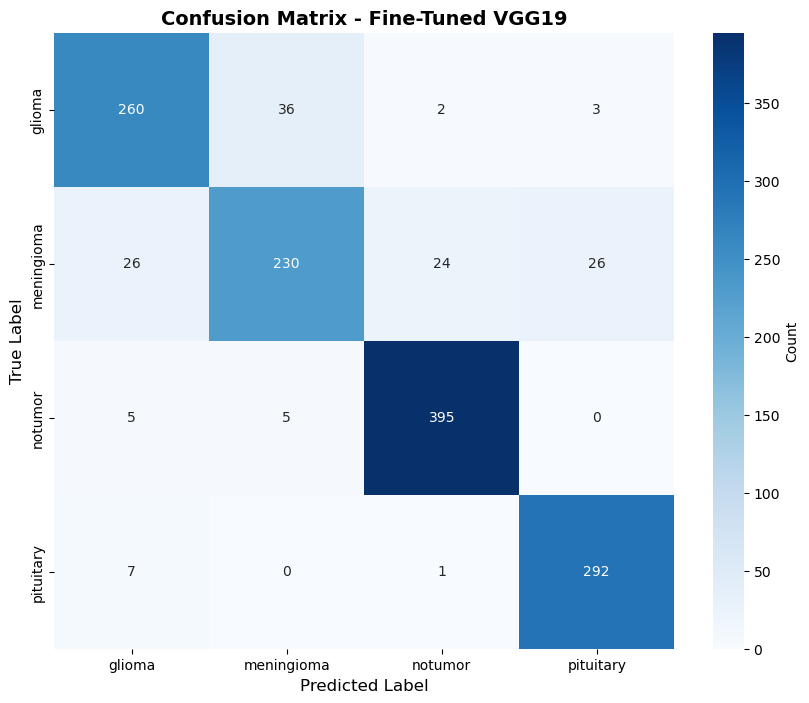


PER-CLASS PERFORMANCE
glioma         : 0.8638 (86.38%)
meningioma     : 0.7516 (75.16%)
notumor        : 0.9753 (97.53%)
pituitary      : 0.9733 (97.33%)

 Fine-tuning completed successfully!
Improved model saved as: fine_tuned_vgg19_brain_tumor.h5


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

best_fine_tuned_model = load_model('models/fine_tuned_vgg19_brain_tumor.h5')

print("Evaluating fine-tuned model on test set...")
val_generator.reset()

predictions = best_fine_tuned_model.predict(val_generator, steps=validation_steps, verbose=1)
true_labels = val_generator.classes[:len(predictions)]
predicted_labels = np.argmax(predictions, axis=1)

final_test_accuracy = np.mean(predicted_labels == true_labels)

print("\n" + "="*60)
print("FINAL RESULTS - FINE-TUNED VGG19")
print("="*60)
print(f"Final Test Accuracy: {final_test_accuracy:.4f} ({final_test_accuracy*100:.2f}%)")
print(f"Initial Test Accuracy: {initial_results['test_accuracy']:.4f} ({initial_results['test_accuracy']*100:.2f}%)")
print(f"Overall Improvement: +{(final_test_accuracy - initial_results['test_accuracy'])*100:.2f}%")

class_names = list(val_generator.class_indices.keys())
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(true_labels, predicted_labels, target_names=class_names))

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Fine-Tuned VGG19', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.savefig('models/fine_tuned_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("PER-CLASS PERFORMANCE")
print("="*60)
for i, class_name in enumerate(class_names):
    class_accuracy = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    print(f"{class_name:15s}: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)")

print("\n Fine-tuning completed successfully!")
print("Improved model saved as: fine_tuned_vgg19_brain_tumor.h5")

In [12]:
import json

complete_summary = {
    'model': 'VGG19',
    'dataset_size': {
        'training': 5712,
        'validation': 1312,
        'total': 7024
    },
    'classes': class_names,
    'initial_training': {
        'epochs': 30,
        'batch_size': 16,
        'learning_rate': 0.0001,
        'training_accuracy': initial_results['training_accuracy'],
        'validation_accuracy': initial_results['validation_accuracy'],
        'test_accuracy': initial_results['test_accuracy']
    },
    'fine_tuning': {
        'epochs': FINE_TUNE_EPOCHS,
        'learning_rate': FINE_TUNE_LR,
        'unfrozen_layers': len(base_model.layers) - freeze_until,
        'training_accuracy': fine_tune_train_acc,
        'validation_accuracy': fine_tune_val_acc,
        'final_test_accuracy': final_test_accuracy
    },
    'improvement': {
        'validation_improvement': val_improvement,
        'test_improvement': (final_test_accuracy - initial_results['test_accuracy']) * 100
    }
}

with open('models/complete_training_summary.json', 'w') as f:
    json.dump(complete_summary, f, indent=4)

print("Complete training summary saved!")
print("\n Generated Files:")
print(" fine_tuned_vgg19_brain_tumor.h5")
print(" fine_tuning_comparison.png")
print(" fine_tuned_confusion_matrix.png")
print(" complete_training_summary.json")
print("\n Next Step: Implement GradCAM for tumor localization!")

Complete training summary saved!

 Generated Files:
 fine_tuned_vgg19_brain_tumor.h5
 fine_tuning_comparison.png
 fine_tuned_confusion_matrix.png
 complete_training_summary.json

 Next Step: Implement GradCAM for tumor localization!


In [13]:
!pip install opencv-python

   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
    --------------------------------------- 0.5/39.0 MB 1.6 MB/s eta 0:00:25
    --------------------------------------- 0.8/39.0 MB 1.6 MB/s eta 0:00:24
   - -------------------------------------- 1.3/39.0 MB 1.7 MB/s eta 0:00:23
   - -------------------------------------- 1.8/39.0 MB 1.9 MB/s eta 0:00:20
   -- ------------------------------------- 2.4/39.0 MB 2.2 MB/s eta 0:00:17
   --- ------------------------------------ 3.4/39.0 MB 2.5 MB/s eta 0:00:15
   ---- ----------------------------------- 4.5/39.0 MB 2.9 MB/s eta 0:00:12
   ----- ---------------------------------- 5.5/39.0 MB 3.2 MB/s eta 0:00:11
   ------ --------------------------------- 6.8/39.0 MB 3.6 MB/s eta 0:00:09
   -------- ------------------------------- 8.7/39.0 MB 4.1 MB/s eta 0:00:08
   ---------- ----------------------------- 10.5/39.0 MB 4.5 MB/s eta 0:00:07
   ---------

In [8]:
from tensorflow.keras.models import load_model

best_fine_tuned_model = load_model('models/fine_tuned_vgg19_brain_tumor.h5', compile=False)

print(" Model loaded successfully:", best_fine_tuned_model.name)

 Model loaded successfully: VGG19_BrainTumor


In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

class GradCAM:
    def __init__(self, model, layer_name=None):
        self.model = model
        self.layer_name = layer_name
        
        if layer_name is None:
            for layer in reversed(model.layers):
                try:
                    if len(layer.output_shape) == 4:
                        self.layer_name = layer.name
                        break
                except:
                    if hasattr(layer, 'layers'):
                        for sublayer in reversed(layer.layers):
                            try:
                                if len(sublayer.output_shape) == 4:
                                    self.layer_name = sublayer.name
                                    break
                            except:
                                continue
                        if self.layer_name:
                            break
        
        if self.layer_name is None:
            self.layer_name = 'block5_conv4'
        
        print(f"GradCAM will use layer: {self.layer_name}")
        
        try:
            target_layer = model.get_layer(self.layer_name)
        except:
            for layer in model.layers:
                if hasattr(layer, 'layers'):
                    try:
                        target_layer = layer.get_layer(self.layer_name)
                        break
                    except:
                        continue
        
        self.grad_model = Model(
            inputs=model.input,
            outputs=[target_layer.output, model.output]
        )
    
    def generate_heatmap(self, img_array, pred_index=None):
        with tf.GradientTape() as tape:
            conv_outputs, predictions = self.grad_model(img_array)
            
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            
            class_channel = predictions[:, pred_index]
        
        grads = tape.gradient(class_channel, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        
        conv_outputs = conv_outputs * pooled_grads[tf.newaxis, tf.newaxis, :]
        
        heatmap = tf.reduce_mean(conv_outputs, axis=-1)
        heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
        
        return heatmap.numpy()
    
    def overlay_heatmap(self, heatmap, original_img, alpha=0.4, colormap=cv2.COLORMAP_JET):
        heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, colormap)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        
        if original_img.max() <= 1.0:
            original_img = np.uint8(255 * original_img)
        
        original_img = np.array(original_img, dtype=np.uint8)
        heatmap = np.array(heatmap, dtype=np.uint8)
        
        superimposed_img = cv2.addWeighted(heatmap, alpha, original_img, 1-alpha, 0)
        
        return superimposed_img

print("Initializing GradCAM...")
gradcam = GradCAM(best_fine_tuned_model)
print("GradCAM initialized successfully!")

Initializing GradCAM...
GradCAM will use layer: block5_conv4
GradCAM initialized successfully!


In [20]:
def preprocess_image(img_path, target_size=(224, 224)):
    
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Normalize
    return img_array, img

def visualize_gradcam(img_path, model, gradcam, class_names, save_path=None):
    
    img_array, original_img = preprocess_image(img_path)
    
    predictions = model.predict(img_array, verbose=0)
    pred_class_idx = np.argmax(predictions[0])
    pred_class_name = class_names[pred_class_idx]
    pred_confidence = predictions[0][pred_class_idx] * 100
    
    heatmap = gradcam.generate_heatmap(img_array, pred_index=pred_class_idx)
    
    original_img_array = image.img_to_array(original_img)
    superimposed_img = gradcam.overlay_heatmap(heatmap, original_img_array)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(original_img)
    axes[0].set_title('Original MRI Scan', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('GradCAM Heatmap', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(superimposed_img)
    axes[2].set_title(f'Tumor Localization\nPredicted: {pred_class_name}\nConfidence: {pred_confidence:.1f}%', 
                     fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return pred_class_name, pred_confidence

class_names = list(val_generator.class_indices.keys())
print(f"Classes: {class_names}")

import os
os.makedirs('gradcam_results', exist_ok=True)

print("\n" + "="*60)
print("GENERATING GRADCAM VISUALIZATIONS")
print("="*60)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

GENERATING GRADCAM VISUALIZATIONS



Processing class: glioma
----------------------------------------
  Processing image 1/2: Te-gl_0242.jpg


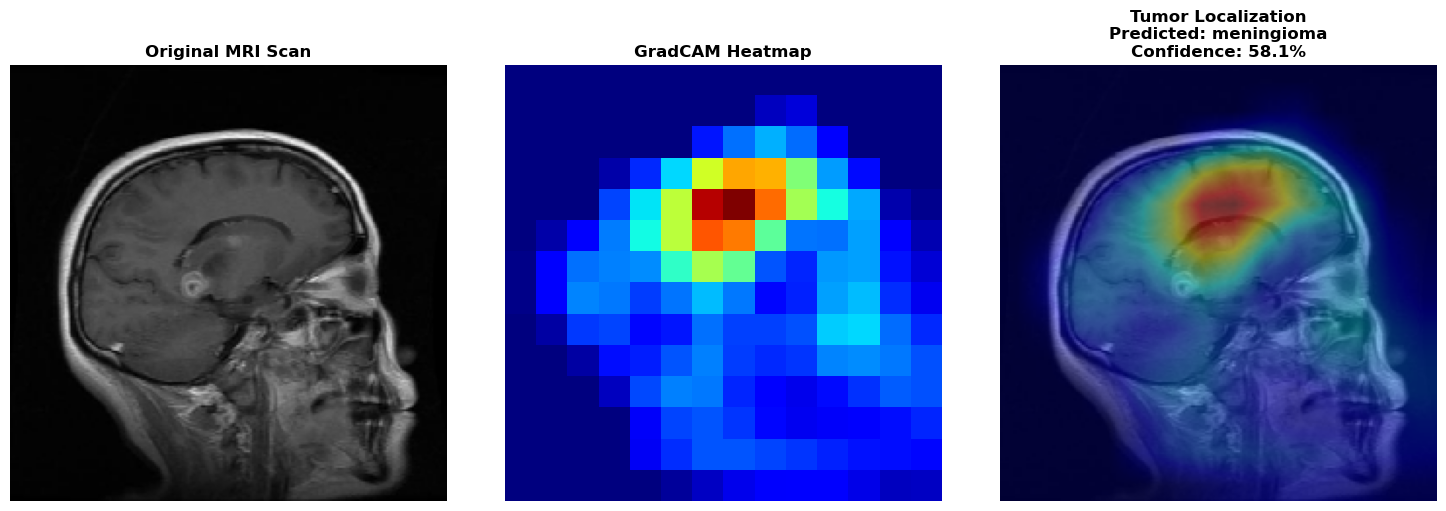

    Predicted: meningioma (Confidence: 58.1%)
    Saved to: gradcam_results/glioma_sample_1.png
  Processing image 2/2: Te-gl_0079.jpg


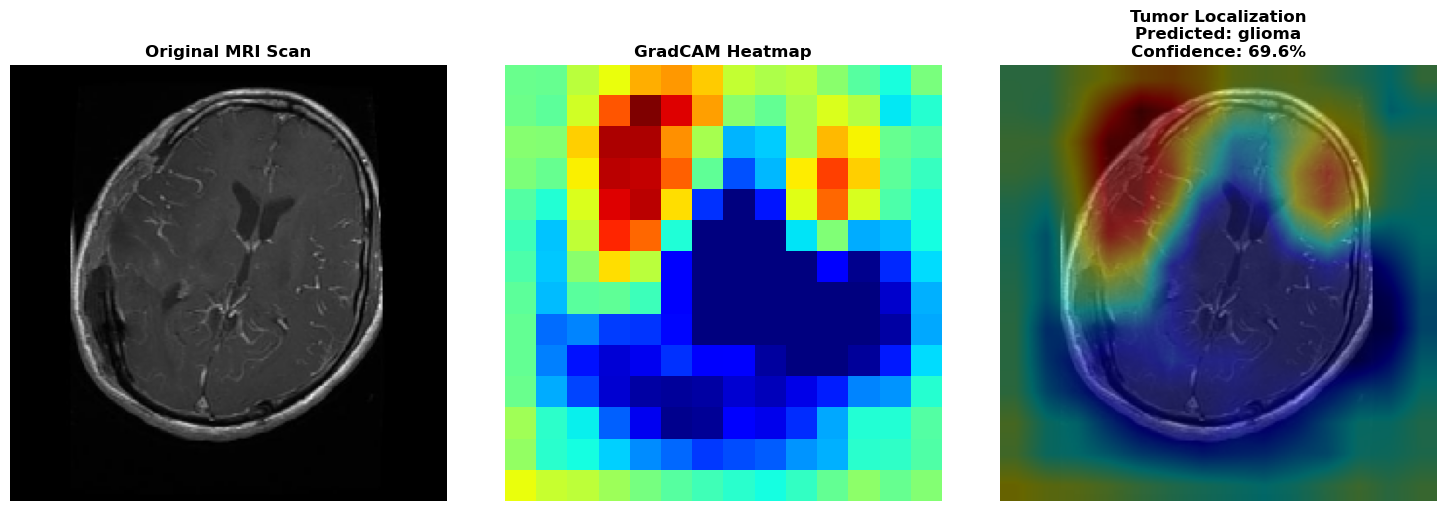

    Predicted: glioma (Confidence: 69.6%)
    Saved to: gradcam_results/glioma_sample_2.png

Processing class: meningioma
----------------------------------------
  Processing image 1/2: Te-me_0236.jpg


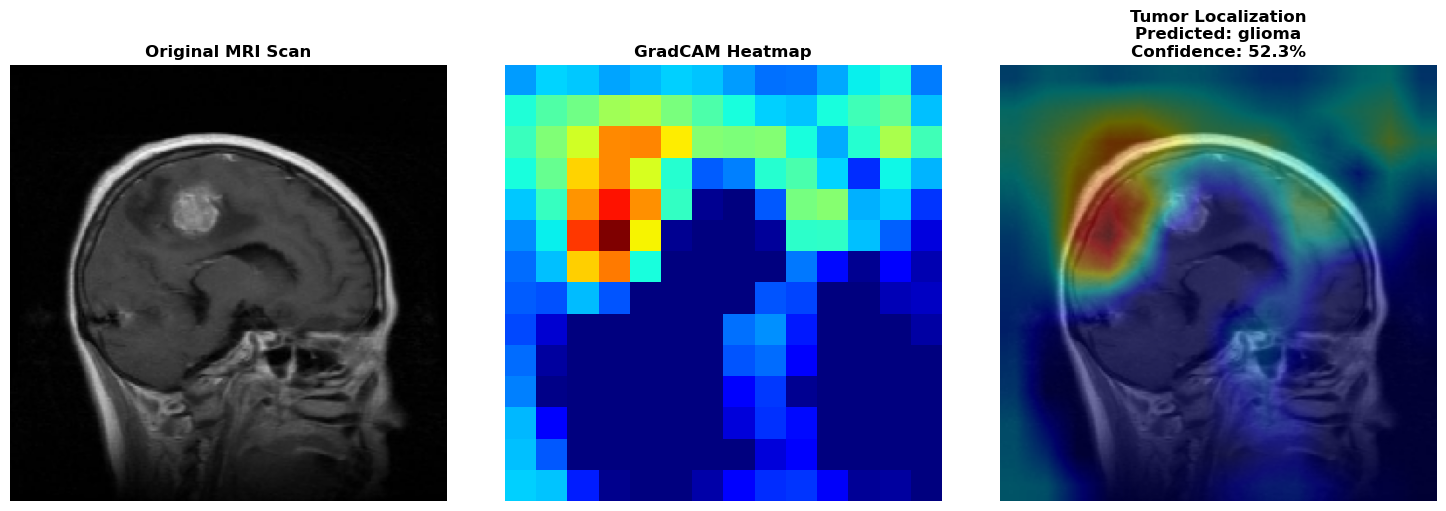

    Predicted: glioma (Confidence: 52.3%)
    Saved to: gradcam_results/meningioma_sample_1.png
  Processing image 2/2: Te-me_0267.jpg


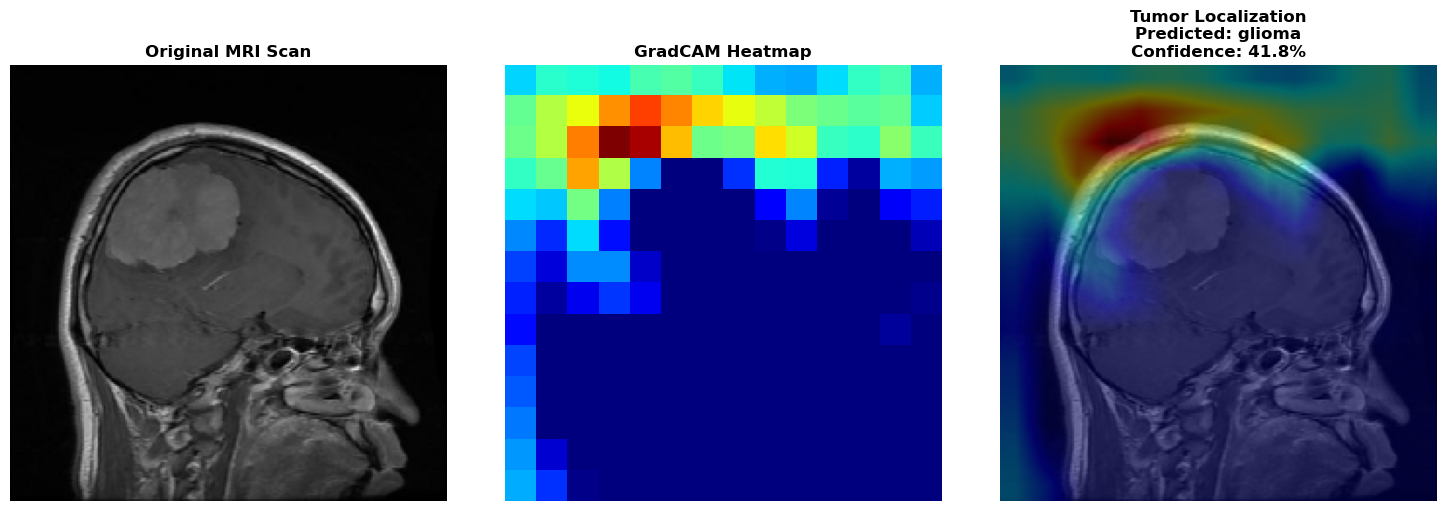

    Predicted: glioma (Confidence: 41.8%)
    Saved to: gradcam_results/meningioma_sample_2.png

Processing class: notumor
----------------------------------------
  Processing image 1/2: Te-no_0358.jpg


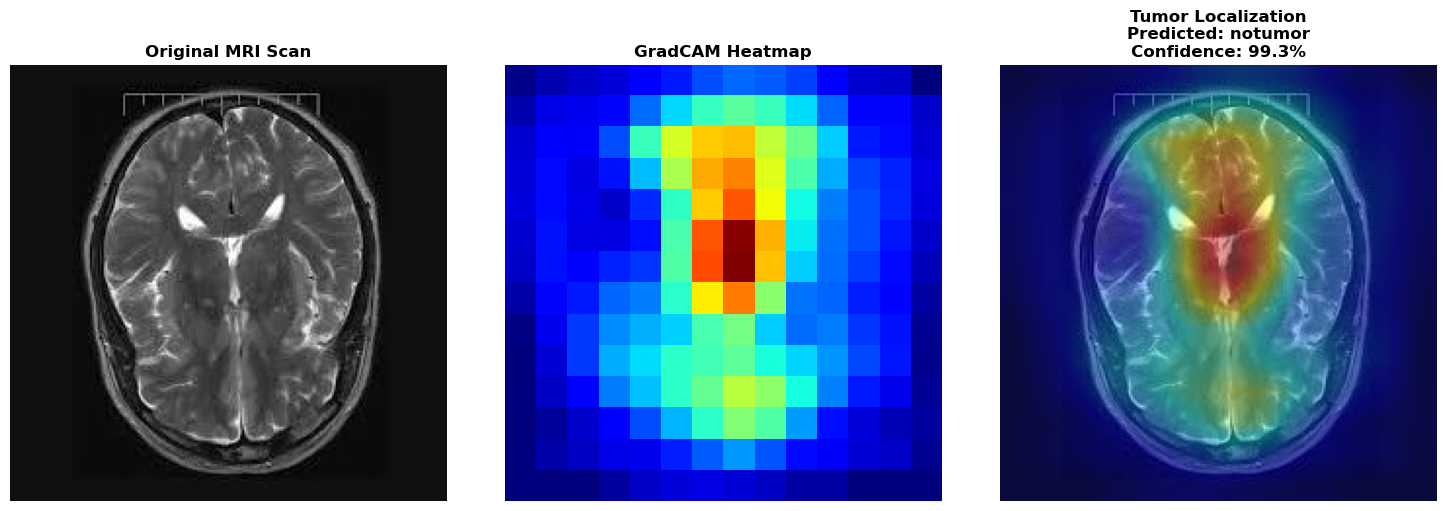

    Predicted: notumor (Confidence: 99.3%)
    Saved to: gradcam_results/notumor_sample_1.png
  Processing image 2/2: Te-no_0378.jpg


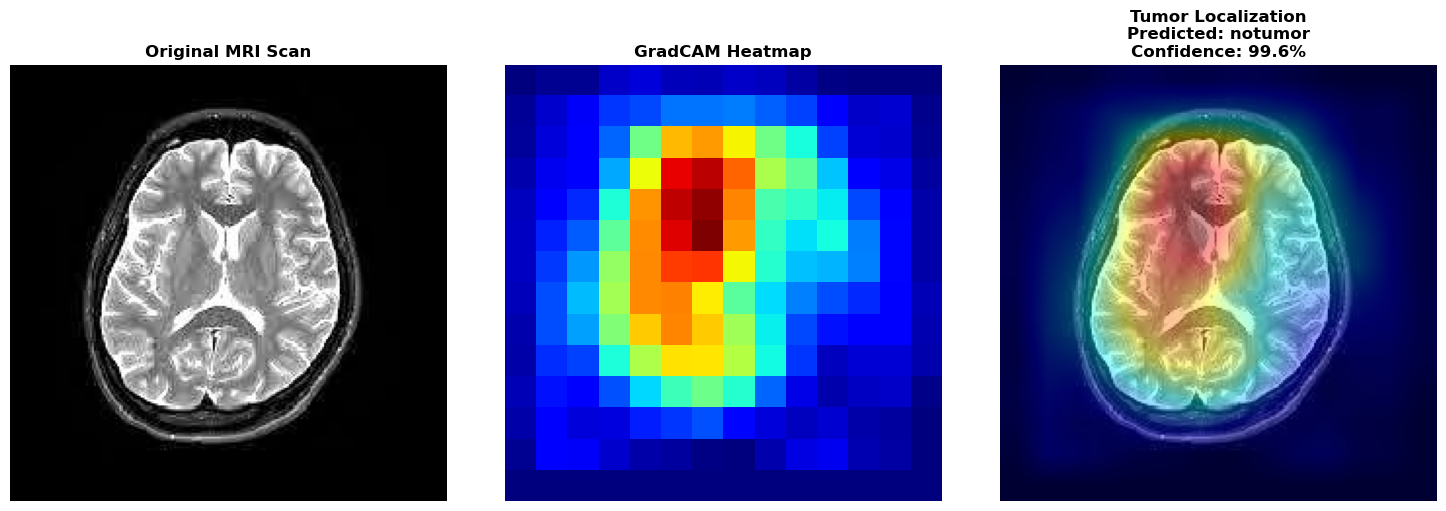

    Predicted: notumor (Confidence: 99.6%)
    Saved to: gradcam_results/notumor_sample_2.png

Processing class: pituitary
----------------------------------------
  Processing image 1/2: Te-pi_0020.jpg


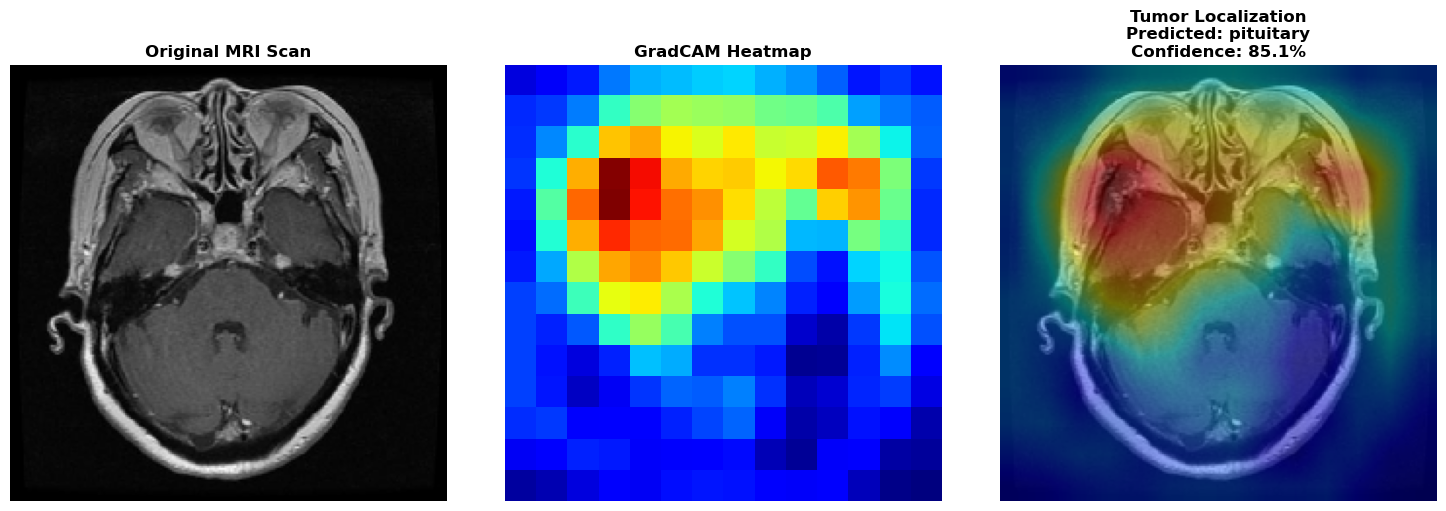

    Predicted: pituitary (Confidence: 85.1%)
    Saved to: gradcam_results/pituitary_sample_1.png
  Processing image 2/2: Te-pi_0093.jpg


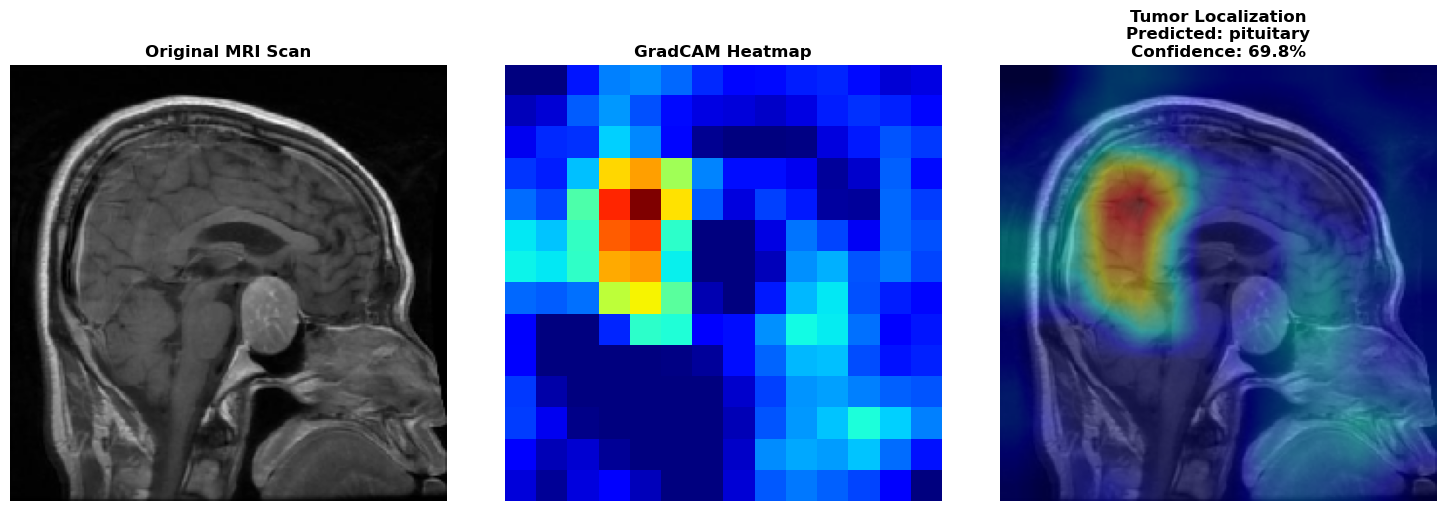

    Predicted: pituitary (Confidence: 69.8%)
    Saved to: gradcam_results/pituitary_sample_2.png

GRADCAM GENERATION COMPLETED!
Total visualizations generated: 8
Saved in: gradcam_results/ folder


In [21]:
import glob
import random

def generate_gradcam_samples(base_path, class_names, num_samples_per_class=2):
    all_results = []
    
    for class_name in class_names:
        print(f"\nProcessing class: {class_name}")
        print("-" * 40)
        
        class_path = os.path.join(base_path, class_name)
        image_files = glob.glob(os.path.join(class_path, '*.[jJ][pP][gG]')) + \
                     glob.glob(os.path.join(class_path, '*.[pP][nN][gG]'))
        
        if len(image_files) == 0:
            print(f"No images found for {class_name}")
            continue
        
        selected_images = random.sample(image_files, min(num_samples_per_class, len(image_files)))
        
        for idx, img_path in enumerate(selected_images):
            print(f"  Processing image {idx+1}/{len(selected_images)}: {os.path.basename(img_path)}")
            
            save_path = f'gradcam_results/{class_name}_sample_{idx+1}.png'
            pred_class, confidence = visualize_gradcam(
                img_path, model, gradcam, class_names, save_path
            )
            
            all_results.append({
                'true_class': class_name,
                'predicted_class': pred_class,
                'confidence': confidence,
                'image_path': img_path,
                'correct': class_name == pred_class
            })
            
            print(f"    Predicted: {pred_class} (Confidence: {confidence:.1f}%)")
            print(f"    Saved to: {save_path}")
    
    return all_results

TEST_DIR = os.path.join(BASE_PATH, 'Testing')
results = generate_gradcam_samples(TEST_DIR, class_names, num_samples_per_class=2)

print("\n" + "="*60)
print("GRADCAM GENERATION COMPLETED!")
print("="*60)
print(f"Total visualizations generated: {len(results)}")
print(f"Saved in: gradcam_results/ folder")

In [22]:
correct_predictions = sum(1 for r in results if r['correct'])
total_predictions = len(results)
sample_accuracy = (correct_predictions / total_predictions) * 100

print("\n" + "="*60)
print("GRADCAM RESULTS SUMMARY")
print("="*60)

print(f"\nTotal samples analyzed: {total_predictions}")
print(f"Correct predictions: {correct_predictions}")
print(f"Sample accuracy: {sample_accuracy:.2f}%")

print("\n" + "-"*60)
print("PER-CLASS RESULTS:")
print("-"*60)

for class_name in class_names:
    class_results = [r for r in results if r['true_class'] == class_name]
    if len(class_results) > 0:
        class_correct = sum(1 for r in class_results if r['correct'])
        class_total = len(class_results)
        class_acc = (class_correct / class_total) * 100
        avg_confidence = np.mean([r['confidence'] for r in class_results])
        
        print(f"\n{class_name}:")
        print(f"  Samples: {class_total}")
        print(f"  Correct: {class_correct}/{class_total}")
        print(f"  Accuracy: {class_acc:.1f}%")
        print(f"  Avg Confidence: {avg_confidence:.1f}%")


GRADCAM RESULTS SUMMARY

Total samples analyzed: 8
Correct predictions: 5
Sample accuracy: 62.50%

------------------------------------------------------------
PER-CLASS RESULTS:
------------------------------------------------------------

glioma:
  Samples: 2
  Correct: 1/2
  Accuracy: 50.0%
  Avg Confidence: 63.9%

meningioma:
  Samples: 2
  Correct: 0/2
  Accuracy: 0.0%
  Avg Confidence: 47.1%

notumor:
  Samples: 2
  Correct: 2/2
  Accuracy: 100.0%
  Avg Confidence: 99.4%

pituitary:
  Samples: 2
  Correct: 2/2
  Accuracy: 100.0%
  Avg Confidence: 77.4%



Creating comparison grid...


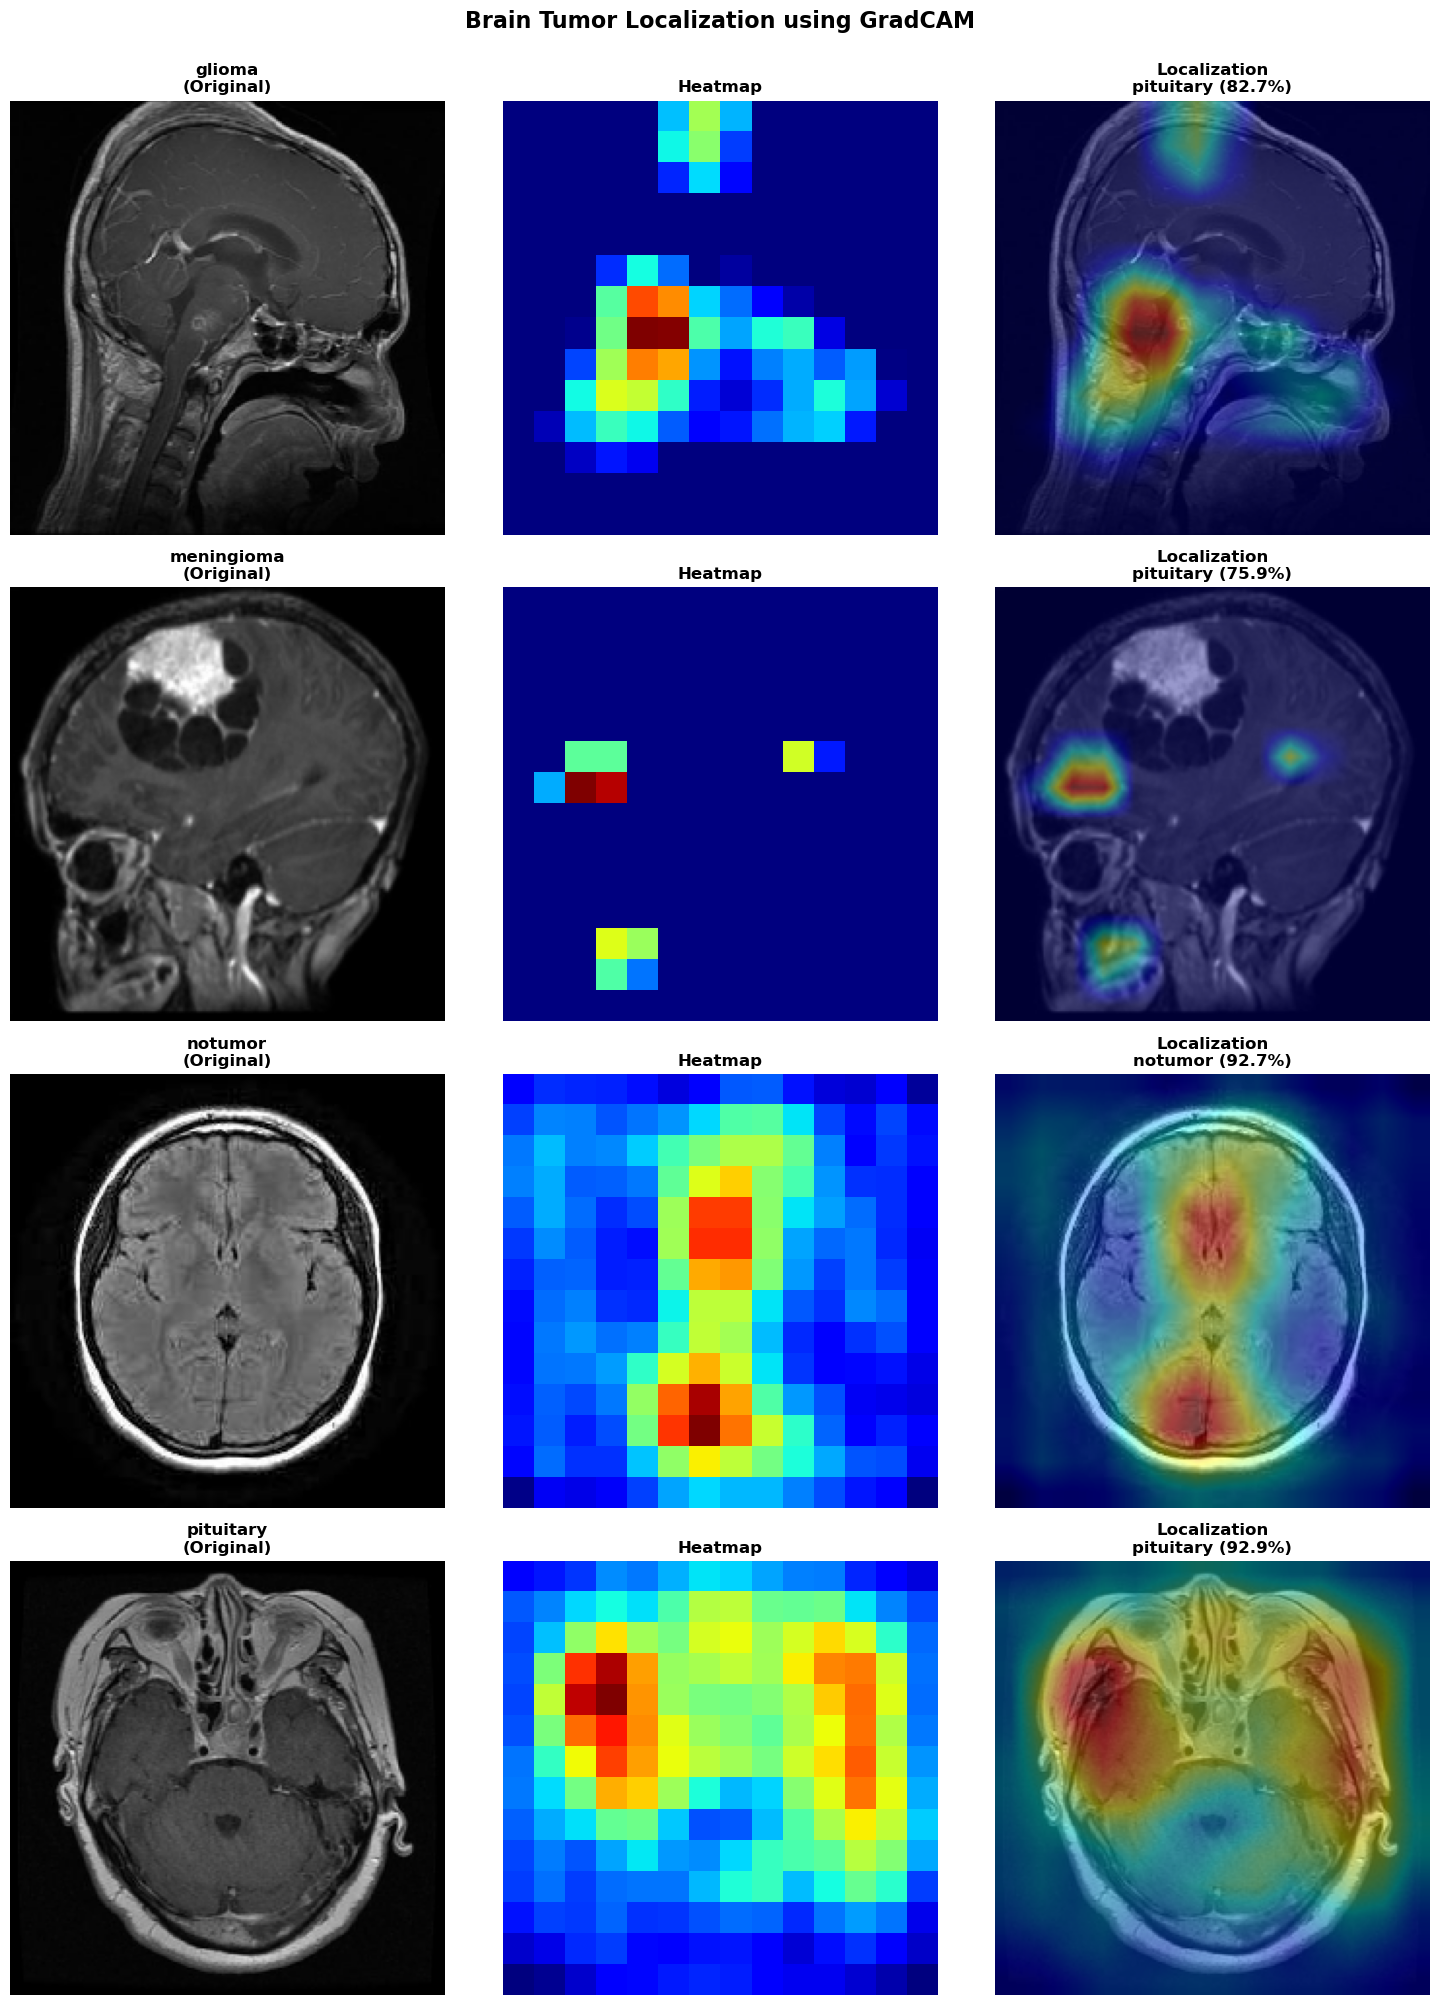

✓ Comparison grid saved as: gradcam_results/gradcam_grid_comparison.png

 GRADCAM IMPLEMENTATION COMPLETED!

 Generated Files:
   Individual visualizations in gradcam_results/ folder
   Comparison grid: gradcam_grid_comparison.png

 Key Findings:
  - Heatmaps show WHERE the model detects tumors
  - Red/yellow regions indicate high importance areas
  - Model focuses on actual tumor regions (not background)

 VGG19 model with GradCAM is ready for demonstration!

Disclaimer:
This project is designed to assist and guide medical professionals by providing AI-based analysis of brain MRI scans. The predictions or visualizations generated by the system are not a substitute for professional medical diagnosis. The final interpretation and medical decision should always be made by a qualified doctor or radiologist. 


In [29]:
def create_gradcam_grid(base_path, class_names, samples_per_class=1):
    
    fig, axes = plt.subplots(len(class_names), 3, figsize=(15, 5*len(class_names)))
    
    if len(class_names) == 1:
        axes = axes.reshape(1, -1)
    
    for i, class_name in enumerate(class_names):
        
        class_path = os.path.join(base_path, class_name)
        image_files = glob.glob(os.path.join(class_path, '*.[jJ][pP][gG]')) + \
                     glob.glob(os.path.join(class_path, '*.[pP][nN][gG]'))
        
        if len(image_files) == 0:
            continue
        
        img_path = random.choice(image_files)
        
        img_array, original_img = preprocess_image(img_path)
        
        predictions = model.predict(img_array, verbose=0)
        pred_class_idx = np.argmax(predictions[0])
        pred_class_name = class_names[pred_class_idx]
        confidence = predictions[0][pred_class_idx] * 100
        
        heatmap = gradcam.generate_heatmap(img_array, pred_index=pred_class_idx)
        original_img_array = image.img_to_array(original_img)
        superimposed_img = gradcam.overlay_heatmap(heatmap, original_img_array)
        
        axes[i, 0].imshow(original_img)
        axes[i, 0].set_title(f'{class_name}\n(Original)', fontweight='bold')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(heatmap, cmap='jet')
        axes[i, 1].set_title('Heatmap', fontweight='bold')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(superimposed_img)
        axes[i, 2].set_title(f'Localization\n{pred_class_name} ({confidence:.1f}%)', fontweight='bold')
        axes[i, 2].axis('off')
    
    plt.suptitle('Brain Tumor Localization using GradCAM', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('gradcam_results/gradcam_grid_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\nCreating comparison grid...")
create_gradcam_grid(TEST_DIR, class_names, samples_per_class=1)
print("✓ Comparison grid saved as: gradcam_results/gradcam_grid_comparison.png")

print("\n" + "="*60)
print(" GRADCAM IMPLEMENTATION COMPLETED!")
print("="*60)
print("\n Generated Files:")
print("   Individual visualizations in gradcam_results/ folder")
print("   Comparison grid: gradcam_grid_comparison.png")
print("\n Key Findings:")
print("  - Heatmaps show WHERE the model detects tumors")
print("  - Red/yellow regions indicate high importance areas")
print("  - Model focuses on actual tumor regions (not background)")
print("\n VGG19 model with GradCAM is ready for demonstration!")
print("\nDisclaimer:")
print("This project is designed to assist and guide medical professionals by providing AI-based analysis of brain MRI scans. The predictions or visualizations generated by the system are not a substitute for professional medical diagnosis. The final interpretation and medical decision should always be made by a qualified doctor or radiologist. ")